In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import time
import numpy as np
import os
import pandas as pd
pd.options.display.max_columns = 100
pd.options.display.max_rows = 130

In [3]:
from utils_data import (
    load_raw_data, check_dups)
from settings_lt_shorts import (
    audio_settings, create_directories, load_data_settings, lt_shorts_categories, load_video_configs
)
from utils_lt_shorts import (
    stitch_audios, draw_lt_vocab_list_whole_image, create_video_with_concat_images
)

In [4]:
import pandas as pd
import numpy as np
import os
import time
import shutil
import datetime
from edge_tts import Communicate
from collections import defaultdict
from PIL import Image, ImageDraw, ImageFont
from moviepy import ImageClip, CompositeVideoClip, AudioFileClip, ColorClip, VideoFileClip
from utils_video import determine_if_text_size_too_big
from pydub import AudioSegment

# Get data

In [5]:
truly_load_data = False
if truly_load_data:
    df_all_vocab = load_raw_data()
    df_all_vocab.to_csv('static/latest_data.csv', index=False)
else:
    df_all_vocab = pd.read_csv('static/latest_data.csv')
    print('!!!!!!!! WARNING: not truly loading data !!!!!!!!')

df_dups = check_dups(df_all_vocab)
print(df_all_vocab.shape)
print(f'# duplicate vocab: {len(df_dups)}')
df_all_vocab.head(3)

!!!!!!!! WARNING: not truly loading data !!!!!!!!
(7489, 38)
# duplicate vocab: 0


,id,chinese,pinyin,english,type,priority,category1,category2,cat_v3,cat2_v3,cat3_v3,hsk_level,known,known_pinyin_prompt,known_english_prompt,quality,word1,word1_english,word2,word2_english,word3,word3_english,word4,word4_english,voice_zh,voice_en,video_notes,sentence,sentence_pinyin,sentence_english,date,source1,source2,funny,per,adu,slang,phonetic
0,160,袋鼠,dài shǔ,kangaroo,word,3.0,animal,zoo,Animals,NaN,哺乳动物,NONE,2.0,1.0,2.0,1.0,口袋,pocket,鼠,rat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,澳大利亚有很多袋鼠,ào dà lì yà yǒu hěn duō dài shǔ,there are many kangaroos in Australia,2025-01-02,NaN,NaN,NaN,5.0,5.0,5.0,NaN
1,161,松鼠,sōng shǔ,squirrel,word,3.0,animal,wild,Animals,NaN,哺乳动物,NONE,2.0,2.0,2.0,1.0,松,pine tree,鼠,rat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,松鼠在树上跳来跳去,sōng shǔ zài shù shàng tiào lái tiào qù,the squirrel jumps around in the tree,2025-01-02,NaN,NaN,NaN,5.0,5.0,5.0,NaN
2,168,长颈鹿,cháng jǐng lù,giraffe,word,2.0,animal,zoo,Animals,NaN,哺乳动物,NONE,4.0,4.0,2.0,1.0,长,long,颈部,neck,鹿,deer,NaN,NaN,NaN,NaN,NaN,动物园有长颈鹿,Dòngwùyuán yǒu chángjǐnglù,There are giraffes in the zoo,2025-01-02,NaN,NaN,NaN,5.0,5.0,5.0,NaN


# Get information for 1 short

In [6]:
# current_category = '动物分类'
# current_category_dict = lt_shorts_categories[current_category]

# data_settings = load_data_settings(current_category_dict)
# create_directories(data_settings)
# data_settings

In [7]:
# df_vocab_list = df_all_vocab[df_all_vocab['chinese'].isin(data_settings['vocab_list'])].reset_index(drop=True)
# df_vocab_list

# Combine audio into one file

In [8]:
# df_durations = stitch_audios(audio_settings, data_settings, None, df_vocab_list)
# df_durations.head()

# Create images

In [9]:
# video_configs = load_video_configs()
# video_configs

In [10]:
# final_img_file_path = draw_lt_vocab_list_whole_image(video_configs, data_settings, df_vocab_list)
# img_show = ImageClip(final_img_file_path, duration=1).with_start(0)
# img_show.display_in_notebook()

# Create video from images

In [11]:
# create_video_with_concat_images(df_durations, df_vocab_list, data_settings)

# All in one cell

In [12]:
current_category = '行星'
current_category_dict = lt_shorts_categories[current_category]
data_settings = load_data_settings(current_category_dict)
create_directories(data_settings)
data_settings

{'chinese': '行星',
 'pinyin': 'xíng xīng',
 'english': 'planet',
 'vocab_list': [['水星', '金星', '地球'], ['火星', '木星', '土星'], ['天王星', '海王星', '冥王星']],
 'output_path': 'output/lt_shorts/行星',
 'output_path_audio': 'output/lt_shorts/行星/audio_files',
 'output_path_images': 'output/lt_shorts/行星/images'}

In [13]:
from utils_lt_shorts import (
    stitch_audios, draw_lt_vocab_list_whole_image, create_video_with_concat_images
)

In [14]:
if data_settings['vocab_list'][0].__class__ == list:
    n_parts = len(data_settings['vocab_list'])
    data_settings['n_parts'] = n_parts
else:
    n_parts = 1

if n_parts > 1:

    for i in range(n_parts):
        df_vocab_list = df_all_vocab[df_all_vocab['chinese'].isin(data_settings['vocab_list'][i])].reset_index(drop=True)
        data_settings['current_part'] = i + 1
        print(f'Processing part {i+1} of {n_parts}')
        df_durations = stitch_audios(audio_settings, data_settings, None, df_vocab_list, part_number=i+1)
        video_configs = load_video_configs()
        final_img_file_path = draw_lt_vocab_list_whole_image(video_configs, data_settings, df_vocab_list)
        img_show = ImageClip(final_img_file_path, duration=1).with_start(0)
        img_show.display_in_notebook()
        create_video_with_concat_images(df_durations, df_vocab_list, data_settings)
else:

    df_vocab_list = df_all_vocab[df_all_vocab['chinese'].isin(data_settings['vocab_list'])].reset_index(drop=True)
    df_durations = stitch_audios(audio_settings, data_settings, None, df_vocab_list)
    video_configs = load_video_configs()
    final_img_file_path = draw_lt_vocab_list_whole_image(video_configs, data_settings, df_vocab_list)
    img_show = ImageClip(final_img_file_path, duration=1).with_start(0)
    # img_show.display_in_notebook()
    create_video_with_concat_images(df_durations, df_vocab_list, data_settings)


Processing part 1 of 3
Audio duration: 28.3s
Adding clip: output/lt_shorts/行星/images/title_only.png for duration 2.0s
Adding clip: output/lt_shorts/行星/images/vocab_word_0_component_only.png for duration 2.6s
Adding clip: output/lt_shorts/行星/images/vocab_word_0_full.png for duration 2.8s
Adding clip: output/lt_shorts/行星/images/vocab_word_0_sentence.png for duration 2.6s
Adding clip: output/lt_shorts/行星/images/vocab_word_1_component_only.png for duration 3.5s
Adding clip: output/lt_shorts/行星/images/vocab_word_1_full.png for duration 3.5s
Adding clip: output/lt_shorts/行星/images/vocab_word_1_sentence.png for duration 2.8s
Adding clip: output/lt_shorts/行星/images/vocab_word_2_component_only.png for duration 3.4s
Adding clip: output/lt_shorts/行星/images/vocab_word_2_full.png for duration 2.9s
Adding clip: output/lt_shorts/行星/images/vocab_word_2_sentence.png for duration 2.3s
Final audio duration: 28.390s
Final video duration before audio set: 28.324s
MoviePy - Building video output/lt_shorts/行

MoviePy - Done.
MoviePy - Writing video output/lt_shorts/行星/行星_video_part1.mp4



MoviePy - Done !
MoviePy - video ready output/lt_shorts/行星/行星_video_part1.mp4
Processing part 2 of 3
Audio duration: 28.4s
Adding clip: output/lt_shorts/行星/images/title_only.png for duration 2.0s
Adding clip: output/lt_shorts/行星/images/vocab_word_0_component_only.png for duration 2.7s
Adding clip: output/lt_shorts/行星/images/vocab_word_0_full.png for duration 3.5s
Adding clip: output/lt_shorts/行星/images/vocab_word_0_sentence.png for duration 2.7s
Adding clip: output/lt_shorts/行星/images/vocab_word_1_component_only.png for duration 3.4s
Adding clip: output/lt_shorts/行星/images/vocab_word_1_full.png for duration 2.7s
Adding clip: output/lt_shorts/行星/images/vocab_word_1_sentence.png for duration 2.9s
Adding clip: output/lt_shorts/行星/images/vocab_word_2_component_only.png for duration 3.5s
Adding clip: output/lt_shorts/行星/images/vocab_word_2_full.png for duration 2.7s
Adding clip: output/lt_shorts/行星/images/vocab_word_2_sentence.png for duration 2.2s
Final audio duration: 28.510s
Final video 

MoviePy - Done.
MoviePy - Writing video output/lt_shorts/行星/行星_video_part2.mp4



MoviePy - Done !
MoviePy - video ready output/lt_shorts/行星/行星_video_part2.mp4
Processing part 3 of 3
Audio duration: 30.3s
Adding clip: output/lt_shorts/行星/images/title_only.png for duration 2.0s
Adding clip: output/lt_shorts/行星/images/vocab_word_0_component_only.png for duration 4.2s
Adding clip: output/lt_shorts/行星/images/vocab_word_0_full.png for duration 3.1s
Adding clip: output/lt_shorts/行星/images/vocab_word_0_sentence.png for duration 2.2s
Adding clip: output/lt_shorts/行星/images/vocab_word_1_component_only.png for duration 4.5s
Adding clip: output/lt_shorts/行星/images/vocab_word_1_full.png for duration 3.0s
Adding clip: output/lt_shorts/行星/images/vocab_word_1_sentence.png for duration 2.2s
Adding clip: output/lt_shorts/行星/images/vocab_word_2_component_only.png for duration 3.5s
Adding clip: output/lt_shorts/行星/images/vocab_word_2_full.png for duration 2.9s
Adding clip: output/lt_shorts/行星/images/vocab_word_2_sentence.png for duration 2.7s
Final audio duration: 30.340s
Final video 

MoviePy - Done.
MoviePy - Writing video output/lt_shorts/行星/行星_video_part3.mp4



MoviePy - Done !
MoviePy - video ready output/lt_shorts/行星/行星_video_part3.mp4



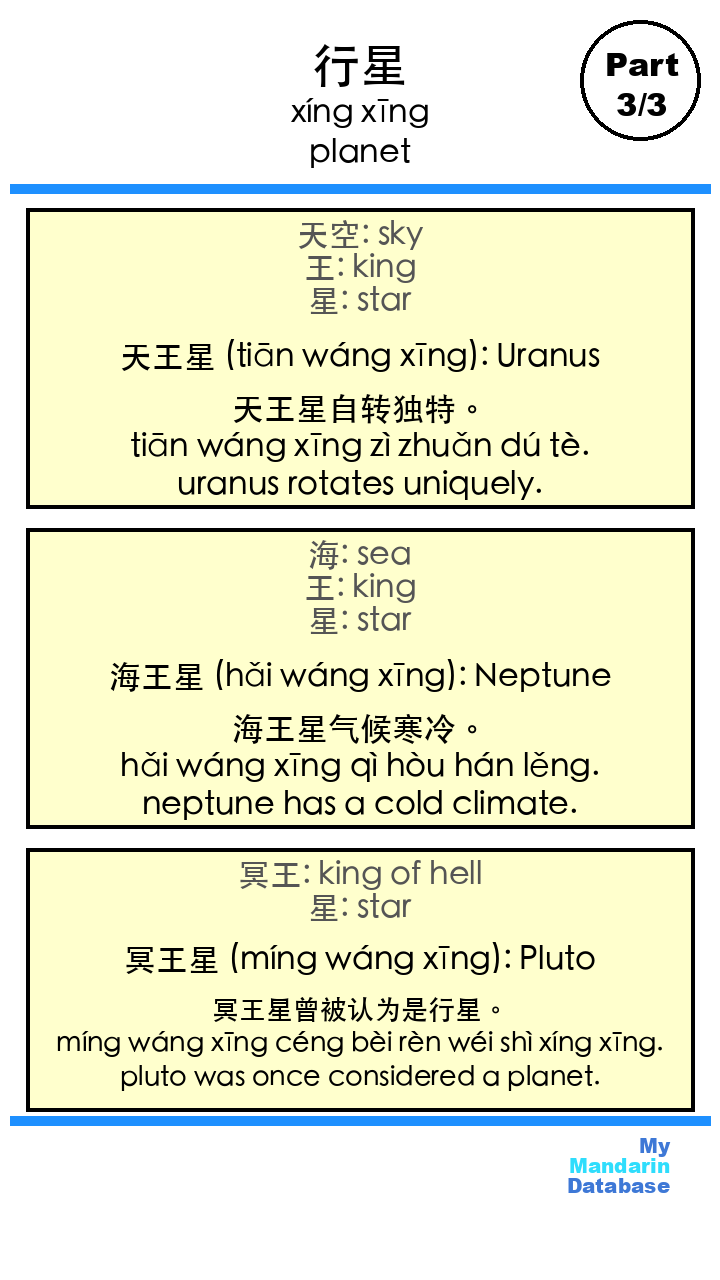

In [15]:
img_show = ImageClip(final_img_file_path, duration=1).with_start(0)
img_show.display_in_notebook()